# Graficas: INS + velocidad/marcha

Grafica los CSV generados por `InsReaders2.py`:
- **ins_data** (`date, ref_id, pos_x, pos_y, pos_z, yaw`): posicion y yaw del INS.
- **speed_gear** (`date, speed_kmh, gear`): velocidad (km/h) y marcha (`-1`=R, `0`=N, `1`=D).

Ajusta los nombres de archivo y, si hace falta, las constantes de escala.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

INS_CSV = r'10_08/ins_data_prueba_02.csv'
SG_CSV  = r'10_08/speed_gear_prueba_02.csv'

# Escalas (las posiciones y el yaw vienen en centesimas)
POS_SCALE = 100.0   # -> metros
YAW_SCALE = 100.0   # -> grados
REF_ID    = 11      # ref_id con la trayectoria real (10000 suele ser el arranque en 0)

ins = pd.read_csv(INS_CSV, parse_dates=['date'])
sg  = pd.read_csv(SG_CSV,  parse_dates=['date'])

# Filtra el ref_id de interes y escala
ins = ins[ins['ref_id'] == REF_ID].reset_index(drop=True)
for c in ['pos_x', 'pos_y', 'pos_z']:
    ins[c] = ins[c] / POS_SCALE
ins['yaw'] = ins['yaw'] / YAW_SCALE

# Tiempo relativo en segundos (el 'date' tiene resolucion de 1 s)
ins['t'] = (ins['date'] - ins['date'].iloc[0]).dt.total_seconds()
sg['t']  = (sg['date']  - sg['date'].iloc[0]).dt.total_seconds()

print(f"INS: {len(ins)} filas (ref_id={REF_ID}) | speed_gear: {len(sg)} filas")
print(f"duracion INS: {ins['t'].iloc[-1]:.0f} s | speed max: {sg['speed_kmh'].max():.1f} km/h")
ins.head()

INS: 17783 filas (ref_id=11) | speed_gear: 37262 filas
duracion INS: 1863 s | speed max: 34.0 km/h


,date,ref_id,pos_x,pos_y,pos_z,yaw,t
0,2026-08-10 14:03:57,11,-1047.17,31.98,77.85,4.06,0.0
1,2026-08-10 14:03:57,11,-1047.17,31.98,77.85,4.06,0.0
2,2026-08-10 14:03:57,11,-1047.17,31.98,77.85,4.06,0.0
3,2026-08-10 14:03:57,11,-1047.17,31.98,77.85,4.06,0.0
4,2026-08-10 14:03:57,11,-1047.17,31.98,77.85,4.06,0.0


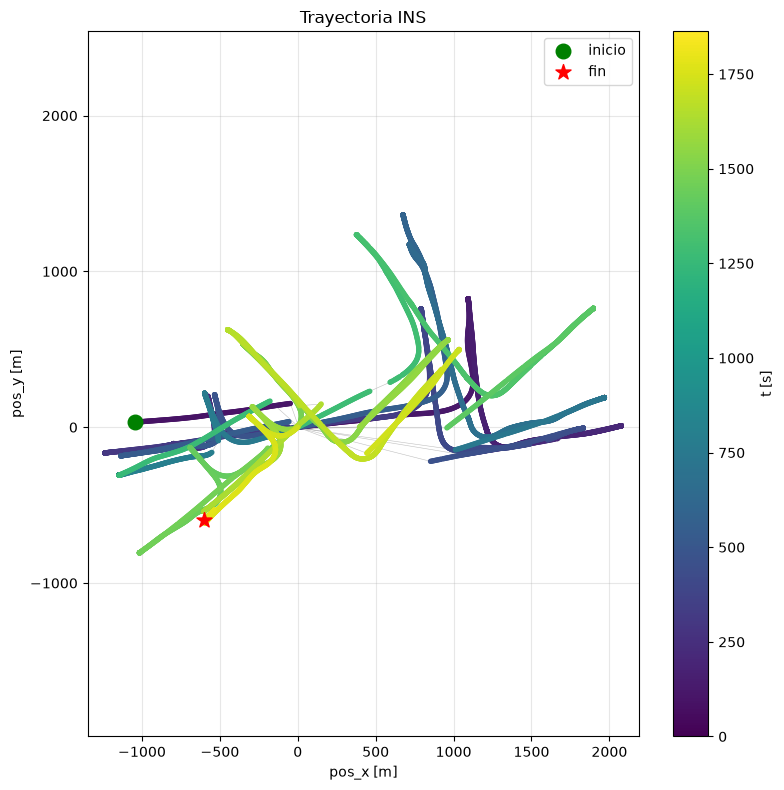

In [2]:
# Trayectoria INS (pos_x vs pos_y) coloreada por tiempo
fig, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(ins['pos_x'], ins['pos_y'], c=ins['t'], cmap='viridis', s=8, zorder=2)
ax.plot(ins['pos_x'], ins['pos_y'], lw=0.4, color='gray', alpha=0.5, zorder=1)
ax.scatter(ins['pos_x'].iloc[0],  ins['pos_y'].iloc[0],  color='green', s=110, marker='o', zorder=3, label='inicio')
ax.scatter(ins['pos_x'].iloc[-1], ins['pos_y'].iloc[-1], color='red',   s=130, marker='*', zorder=3, label='fin')
ax.set_xlabel('pos_x [m]'); ax.set_ylabel('pos_y [m]')
ax.set_title('Trayectoria INS')
ax.set_aspect('equal', adjustable='datalim'); ax.grid(alpha=0.3); ax.legend()
fig.colorbar(sc, ax=ax, label='t [s]')
plt.tight_layout(); plt.show()

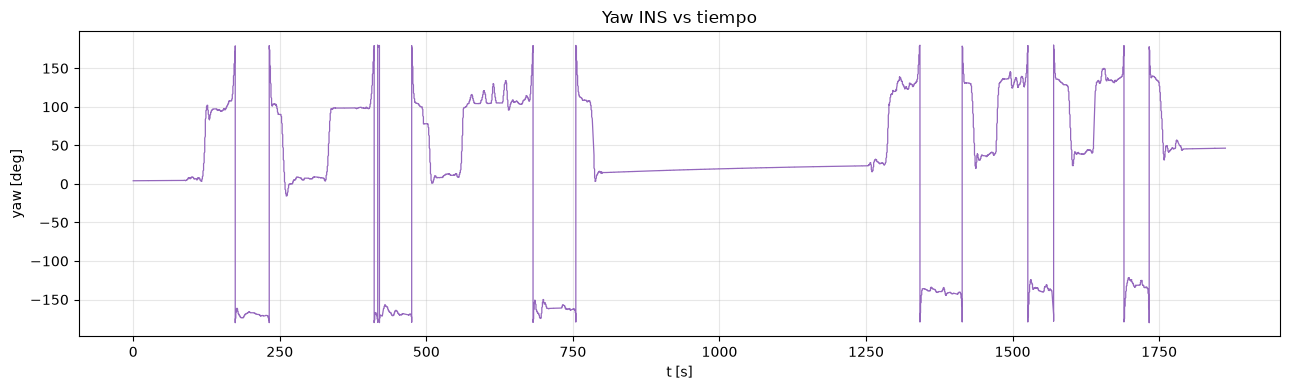

In [3]:
# Yaw del INS vs tiempo
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(ins['t'], ins['yaw'], lw=0.9, color='tab:purple')
ax.set_xlabel('t [s]'); ax.set_ylabel('yaw [deg]')
ax.set_title('Yaw INS vs tiempo')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

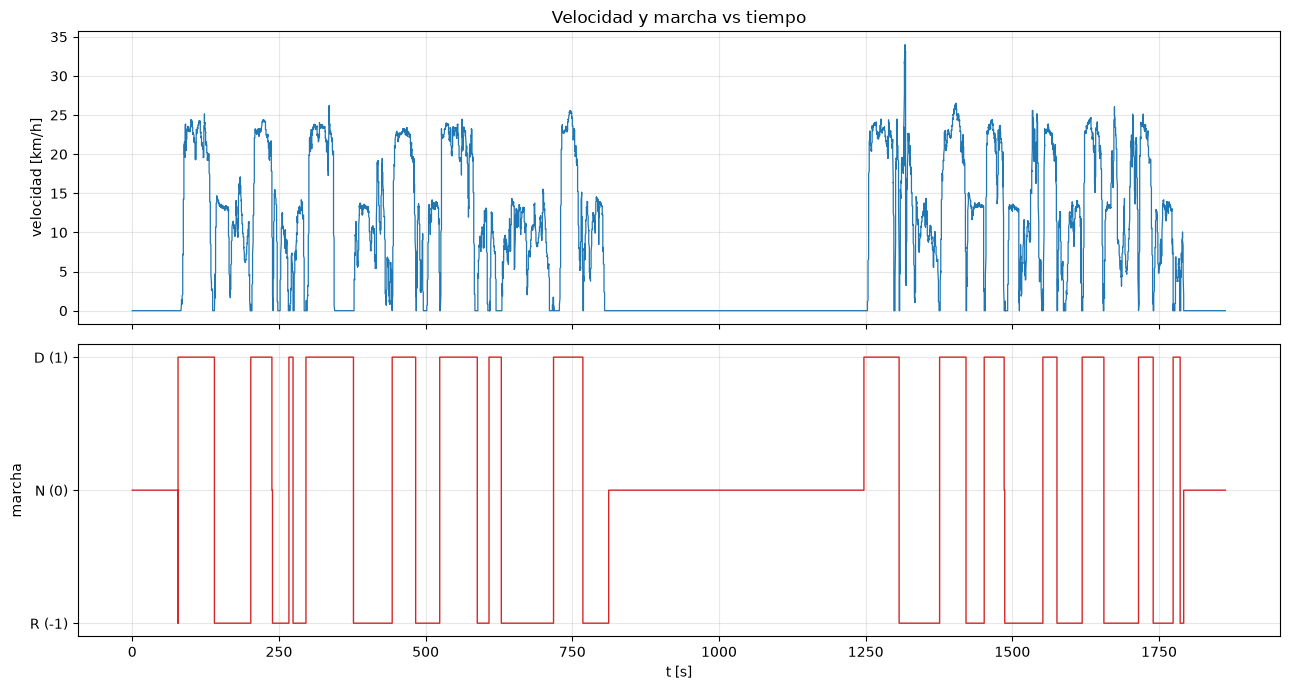

In [4]:
# Velocidad y marcha vs tiempo (eje compartido)
fig, (a1, a2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

a1.plot(sg['t'], sg['speed_kmh'], lw=0.9, color='tab:blue')
a1.set_ylabel('velocidad [km/h]')
a1.set_title('Velocidad y marcha vs tiempo')
a1.grid(alpha=0.3)

a2.step(sg['t'], sg['gear'], where='post', lw=1.0, color='tab:red')
a2.set_yticks([-1, 0, 1]); a2.set_yticklabels(['R (-1)', 'N (0)', 'D (1)'])
a2.set_ylabel('marcha'); a2.set_xlabel('t [s]')
a2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

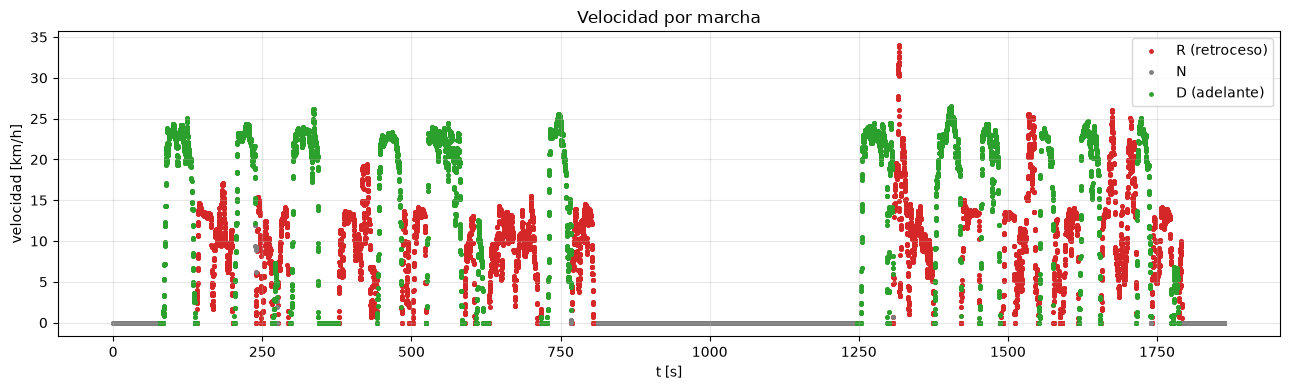

In [5]:
# Velocidad coloreada por marcha (R / N / D)
colores = {-1: 'tab:red', 0: 'tab:gray', 1: 'tab:green'}
nombres = {-1: 'R (retroceso)', 0: 'N', 1: 'D (adelante)'}
fig, ax = plt.subplots(figsize=(13, 4))
for g, c in colores.items():
    m = sg['gear'] == g
    ax.scatter(sg['t'][m], sg['speed_kmh'][m], s=6, color=c, label=nombres[g])
ax.set_xlabel('t [s]'); ax.set_ylabel('velocidad [km/h]')
ax.set_title('Velocidad por marcha')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

## Integracion de la velocidad (signo por marcha)

Se integra la velocidad en el tiempo usando la **marcha** para el signo: D (`+1`) suma (ida) y R (`-1`)
resta (vuelta). Como el `date` tiene resolucion de 1 s con varias muestras por segundo, primero se
agrega por segundo (velocidad media, marcha dominante) y se integra con `dt` = 1 s. Asi se compara si
el desplazamiento de ida iguala al de vuelta (es decir, si cierra a cero).

In [6]:
# Agrega por segundo e integra la velocidad con signo segun la marcha
seg = (sg.groupby('date')
         .agg(speed_kmh=('speed_kmh', 'mean'),
              gear=('gear', lambda x: x.dropna().mode().iloc[0] if x.dropna().size else np.nan))
         .reset_index())
seg['t'] = (seg['date'] - seg['date'].iloc[0]).dt.total_seconds()
seg['dt'] = seg['t'].diff().fillna(0.0)
seg['v_ms'] = seg['speed_kmh'] / 3.6          # km/h -> m/s
seg['gear'] = seg['gear'].fillna(0)

seg['ds'] = seg['v_ms'] * seg['dt']           # distancia recorrida en cada paso [m]
seg['ds_signed'] = np.sign(seg['gear']) * seg['ds']
seg['s'] = seg['ds_signed'].cumsum()          # desplazamiento acumulado con signo

D_ida    = seg.loc[seg['gear'] > 0, 'ds'].sum()   # distancia en D (adelante)
D_vuelta = seg.loc[seg['gear'] < 0, 'ds'].sum()   # distancia en R (retroceso)
neto = seg['s'].iloc[-1]

print('Desplazamiento IDA    (D, +): {:.1f} m'.format(D_ida))
print('Desplazamiento VUELTA (R, -): {:.1f} m'.format(D_vuelta))
print('Diferencia |ida| - |vuelta| : {:+.1f} m'.format(D_ida - D_vuelta))
print('Neto (0 si son iguales)     : {:+.1f} m'.format(neto))
print('Distancia total recorrida   : {:.1f} m'.format(seg['ds'].sum()))

Desplazamiento IDA    (D, +): 2754.8 m
Desplazamiento VUELTA (R, -): 1881.3 m
Diferencia |ida| - |vuelta| : +873.5 m
Neto (0 si son iguales)     : +873.5 m
Distancia total recorrida   : 4636.6 m


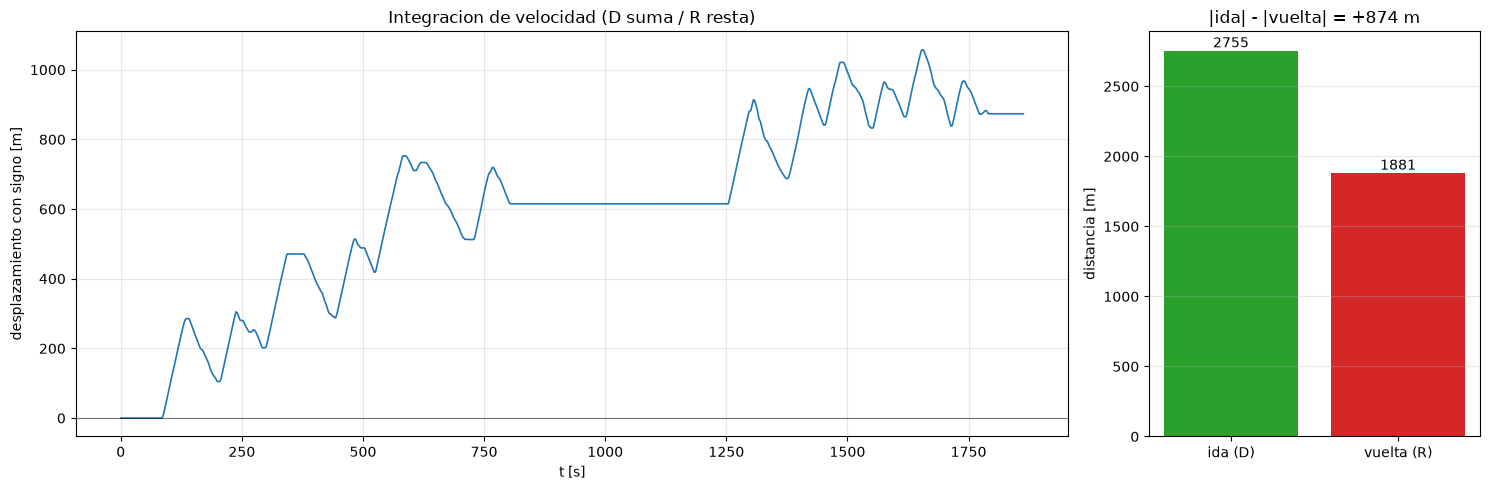

In [7]:
# Desplazamiento acumulado con signo + comparacion ida/vuelta
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [3, 1]})

a1.plot(seg['t'], seg['s'], lw=1.2, color='tab:blue')
a1.axhline(0, color='k', lw=0.8, alpha=0.5)
a1.set_xlabel('t [s]'); a1.set_ylabel('desplazamiento con signo [m]')
a1.set_title('Integracion de velocidad (D suma / R resta)')
a1.grid(alpha=0.3)

a2.bar(['ida (D)', 'vuelta (R)'], [D_ida, D_vuelta], color=['tab:green', 'tab:red'])
a2.set_ylabel('distancia [m]')
a2.set_title(f'|ida| - |vuelta| = {D_ida - D_vuelta:+.0f} m')
for i, v in enumerate([D_ida, D_vuelta]):
    a2.text(i, v, f'{v:.0f}', ha='center', va='bottom')
a2.grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()